<a href="https://colab.research.google.com/github/Resmi-p/Data-Analysis/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

THRIVE DATA PRACTICE


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Thrive_Data_Practice.xlsx to Thrive_Data_Practice.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel('Thrive_Data_Practice.xlsx')

df.head()

,Department,Staff_Name,Epic_Logins,Training_Completed,Avg_Task_Time_Min,Errors_Reported,Records_Processed,User_Satisfaction
0,Ward A,John Smith,45,Yes,4,1,120,8
1,Ward B,Emma Jones,20,No,11,5,80,5
2,Radiology,Sarah Patel,50,Yes,3,0,150,9
3,A&E,Olivia White,42,Yes,6,2,140,8
4,Cardiology,James Wilson,35,Yes,5,1,115,7


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Department          20 non-null     object
 1   Staff_Name          20 non-null     object
 2   Epic_Logins         20 non-null     int64 
 3   Training_Completed  20 non-null     object
 4   Avg_Task_Time_Min   20 non-null     int64 
 5   Errors_Reported     20 non-null     int64 
 6   Records_Processed   20 non-null     int64 
 7   User_Satisfaction   20 non-null     int64 
dtypes: int64(5), object(3)
memory usage: 1.4+ KB


In [ ]:
df.isnull().sum()

,0
Department,0
Staff_Name,0
Epic_Logins,0
Training_Completed,0
Avg_Task_Time_Min,0
Errors_Reported,0
Records_Processed,0
User_Satisfaction,0


In [ ]:
import sqlite3

conn = sqlite3.connect('hospital.db')

df.to_sql('ThriveData', conn, if_exists='replace', index=False)

20

In [ ]:
query = """
SELECT *
FROM ThriveData
"""

pd.read_sql(query, conn)


,Department,Staff_Name,Epic_Logins,Training_Completed,Avg_Task_Time_Min,Errors_Reported,Records_Processed,User_Satisfaction
0,Ward A,John Smith,45,Yes,4,1,120,8
1,Ward B,Emma Jones,20,No,11,5,80,5
2,Radiology,Sarah Patel,50,Yes,3,0,150,9
3,A&E,Olivia White,42,Yes,6,2,140,8
4,Cardiology,James Wilson,35,Yes,5,1,115,7
5,Ward C,Daniel Brown,18,No,12,6,70,4
6,ICU,Mia Lewis,55,Yes,3,0,160,9
7,Neurology,Liam Harris,47,Yes,4,1,135,8
8,Ward D,Sophia Taylor,22,No,10,4,85,5
9,Oncology,Amelia Young,36,Yes,5,2,125,7


In [ ]:
query = """
SELECT Staff_Name
FROM ThriveData
"""

pd.read_sql(query, conn)


,Staff_Name
0,John Smith
1,Emma Jones
2,Sarah Patel
3,Olivia White
4,James Wilson
5,Daniel Brown
6,Mia Lewis
7,Liam Harris
8,Sophia Taylor
9,Amelia Young


In [ ]:
query = """
SELECT COUNT (DISTINCT Staff_Name )
FROM ThriveData
"""

pd.read_sql(query, conn)

,COUNT (DISTINCT Staff_Name )
0,20


In [ ]:
query = """
SELECT * FROM ThriveData
WHERE Training_Completed = 'Yes'
"""

pd.read_sql(query, conn)


,Department,Staff_Name,Epic_Logins,Training_Completed,Avg_Task_Time_Min,Errors_Reported,Records_Processed,User_Satisfaction
0,Ward A,John Smith,45,Yes,4,1,120,8
1,Radiology,Sarah Patel,50,Yes,3,0,150,9
2,A&E,Olivia White,42,Yes,6,2,140,8
3,Cardiology,James Wilson,35,Yes,5,1,115,7
4,ICU,Mia Lewis,55,Yes,3,0,160,9
5,Neurology,Liam Harris,47,Yes,4,1,135,8
6,Oncology,Amelia Young,36,Yes,5,2,125,7
7,Paediatrics,Benjamin Allen,44,Yes,4,1,145,8
8,Dermatology,Ethan Walker,28,Yes,7,2,95,6
9,Pharmacy,Ella Adams,48,Yes,4,1,155,9


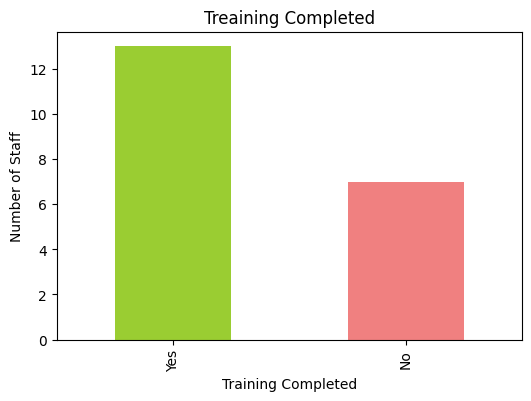

In [ ]:
import matplotlib.pyplot as plt

training_counts = df['Training_Completed'].value_counts()

plt.figure(figsize=(6,4))
training_counts.plot(kind='bar', color=['yellowgreen','lightcoral'])
plt.title('Treaining Completed')
plt.xlabel('Training Completed')
plt.ylabel('Number of Staff')
plt.show()

In [ ]:
query = """
SELECT COUNT(Training_Completed)
FROM ThriveData
WHERE Training_Completed = 'Yes'
"""

pd.read_sql(query, conn)


,COUNT(Training_Completed)
0,13


In [ ]:
query = """
SELECT Staff_Name
FROM ThriveData
WHERE Department = 'Cardiology'
"""

pd.read_sql(query, conn)


,Staff_Name
0,James Wilson


In [ ]:
query = """
SELECT Staff_Name, Avg_Task_Time_Min
FROM ThriveData
WHERE Avg_Task_Time_Min > 10;
"""

pd.read_sql(query, conn)


,Staff_Name,Avg_Task_Time_Min
0,Emma Jones,11
1,Daniel Brown,12
2,Noah Clark,13
3,Charlotte Hall,11
4,Henry Green,12


In [ ]:
query = """
SELECT Department
FROM ThriveData
ORDER BY  Records_Processed;
"""

pd.read_sql(query, conn)

,Department
0,Ward E
1,Ward H
2,Ward C
3,Ward F
4,Ward B
5,Ward G
6,Ward D
7,Dermatology
8,Orthopaedics
9,Physiotherapy


In [ ]:
Average task time by department

In [ ]:
query = """
SELECT Department,
AVG(Avg_Task_Time_Min) AS Avg_Time
FROM ThriveData
GROUP BY Department
---ORDER BY Avg_Time DESC;
"""

pd.read_sql(query, conn)


,Department,Avg_Time
0,A&E,6.0
1,Cardiology,5.0
2,Dermatology,7.0
3,ICU,3.0
4,Neurology,4.0
5,Oncology,5.0
6,Orthopaedics,6.0
7,Outpatients,5.0
8,Paediatrics,4.0
9,Pharmacy,4.0


In [ ]:
6. Total errors reported by department

In [ ]:
query = """
SELECT Department,
SUM(Errors_Reported) AS ERRORS
FROM ThriveData
GROUP BY Department
ORDER BY ERRORS DESC;
"""

pd.read_sql(query, conn)


,Department,ERRORS
0,Ward E,7
1,Ward H,6
2,Ward C,6
3,Ward F,5
4,Ward B,5
5,Ward G,4
6,Ward D,4
7,Outpatients,2
8,Orthopaedics,2
9,Oncology,2


Compare

In [ ]:
query = """

SELECT Training_Completed,
AVG (User_Satisfaction) AS Satisfaction
FROM ThriveData
GROUP BY Training_Completed
ORDER BY Satisfaction DESC;
"""

pd.read_sql(query, conn)


,Training_Completed,Satisfaction
0,Yes,7.692308
1,No,4.571429


top 5 staff with highest Epic logins

In [ ]:
query = """

SELECT Staff_Name, Epic_Logins
FROM ThriveData
ORDER  BY Epic_Logins DESC
LIMIT 5
"""
pd.read_sql(query, conn)


,Staff_Name,Epic_Logins
0,Mia Lewis,55
1,Sarah Patel,50
2,Ella Adams,48
3,Liam Harris,47
4,John Smith,45


In [ ]:
query = """

SELECT Epic_Logins
FROM ThriveData
ORDER  BY Epic_Logins DESC

"""
pd.read_sql(query, conn)

,Epic_Logins
0,55
1,50
2,48
3,47
4,45
5,44
6,42
7,38
8,36
9,35


In [ ]:
query = """

SELECT Staff_Name, Epic_Logins
FROM ThriveData

LIMIT 5

"""
pd.read_sql(query, conn)


,Staff_Name,Epic_Logins
0,John Smith,45
1,Emma Jones,20
2,Sarah Patel,50
3,Olivia White,42
4,James Wilson,35


In [ ]:
query = """

SELECT Staff_Name,
Records_Processed/Avg_Task_Time_Min AS Efficiency
FROM ThriveData
ORDER BY Efficiency DESC
"""

pd.read_sql(query, conn)

,Staff_Name,Efficiency
0,Mia Lewis,53
1,Sarah Patel,50
2,Ella Adams,38
3,Benjamin Allen,36
4,Liam Harris,33
5,John Smith,30
6,Amelia Young,25
7,Olivia White,23
8,James Wilson,23
9,Michael Lee,22


above average satisfaction

In [ ]:
query = """

SELECT Department,
AVG(User_Satisfaction) AS Satisfaction
FROM ThriveData
GROUP BY Department
HAVING AVG(User_Satisfaction) > (SELECT AVG(User_Satisfaction) FROM ThriveData )
ORDER BY Satisfaction DESC;
"""

pd.read_sql(query, conn)

,Department,Satisfaction
0,Radiology,9.0
1,Pharmacy,9.0
2,ICU,9.0
3,Ward A,8.0
4,Paediatrics,8.0
5,Neurology,8.0
6,A&E,8.0
7,Physiotherapy,7.0
8,Outpatients,7.0
9,Orthopaedics,7.0
